# Template: CLV, Churn Probability & Customer Segmentation

Este notebook implementa:
1. **BG/NBD model** para predecir compras futuras y probabilidad de fuga (`prob_alive`)
2. **Gamma-Gamma model** para estimar Customer Lifetime Value (CLV)
3. **KMeans + PCA** para segmentar clientes

### Columnas mínimas requeridas en el DataFrame de transacciones:
| Columna | Descripción |
|---|---|
| `customer_id` | Identificador único del cliente |
| `date` | Fecha de la transacción |
| `amount` | Monto de la transacción |

### Columnas opcionales para clustering:
| Columna | Descripción |
|---|---|
| `channel` | Canal de venta (ej: online, tienda) |
| `category` | Categoría del producto |
| `units` | Unidades compradas |
| `discount` | Si hubo descuento (0/1) |

## 0. Instalación de dependencias

In [ ]:
#!pip install lifetimes yellowbrick scikit-learn pandas numpy matplotlib seaborn

## 1. Carga de datos

Reemplaza la sección de datos sintéticos con tu propio DataFrame de transacciones.
El DataFrame debe tener al menos las columnas: `customer_id`, `date`, `amount`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# OPCIÓN A: Cargar tu propio archivo
# ============================================================
# path_ventas = "datos/BD2526_oct_mar_ventasxfacturas(con_zonas).csv"
# df = pd.read_csv('tu_archivo.csv')
# df = df.rename(columns={
#     'TU_COL_CLIENTE': 'customer_id',
#     'TU_COL_FECHA':   'date',
#     'TU_COL_MONTO':   'amount',
# })

# ============================================================
# OPCIÓN B: Datos sintéticos para probar el pipeline
# ============================================================
# np.random.seed(42)
# n_customers = 500
# n_transactions = 5000

# customer_ids = [f'C{str(i).zfill(4)}' for i in range(n_customers)]

# df = pd.DataFrame({
#     'customer_id': np.random.choice(customer_ids, n_transactions),
#     'date': pd.to_datetime('2022-01-01') + pd.to_timedelta(np.random.randint(0, 730, n_transactions), unit='D'),
#     'amount': np.random.exponential(scale=50, size=n_transactions).round(2) + 10,
#     'units': np.random.randint(1, 5, n_transactions),
#     'channel': np.random.choice(['online', 'store'], n_transactions, p=[0.3, 0.7]),
#     'discount': np.random.choice([0, 1], n_transactions, p=[0.7, 0.3]),
# })

# print(f"Transacciones: {len(df):,}")
# print(f"Clientes únicos: {df['customer_id'].nunique():,}")
# df.head()

In [50]:
path_ventas = "datos/BD2526_oct_mar_ventasxfacturas(con_zonas).csv"
ventas = pd.read_csv(path_ventas)

canales_relevantes = [
    "COBERTURA",
    "VOLUMEN COBERTURA",
    # "MAYORISTAS CADENAS",
    # "MAYORISTA B VOLUMEN",
    # "OTROS MAYORISTAS",
    # "HORECA VOLUMEN",
    # "OTROS HORECA",
]
ventas = ventas[ventas["Nombre Consolidado"].isin(canales_relevantes)]
ventas["Fecha Factura"] = pd.to_datetime(ventas["Fecha Factura"], format="%Y%m%d")

ventas_agrupadas = ventas.groupby(["Cod Cliente", "Fecha Factura"]).agg({
    "Monto Real": "sum"
}).reset_index()

df = ventas_agrupadas.rename(columns={
    'Cod Cliente': 'customer_id',
    'Fecha Factura':   'date',
    'Monto Real':   'amount',
})

print(f"Transacciones: {len(df):,}")
print(f"Clientes únicos: {df['customer_id'].nunique():,}")
df.head()

Transacciones: 605,367
Clientes únicos: 38,368


,customer_id,date,amount
0,235,2025-10-14,30176
1,235,2025-10-21,30067
2,235,2025-10-28,35168
3,235,2025-11-04,28454
4,235,2025-11-18,50285


## 2. Preparación: resumen RFM

Convertimos transacciones individuales al formato RFM requerido por los modelos:
- **frequency**: número de recompras (períodos con compra, excluyendo la primera)
- **recency**: días entre primera y última compra
- **T**: días entre primera compra y fecha de corte
- **monetary_value**: monto promedio por transacción

In [45]:
from lifetimes.utils import summary_data_from_transaction_data

df['date'] = pd.to_datetime(df['date'])
observation_period_end = df['date'].max().strftime('%Y-%m-%d')
print(f"Fecha de corte: {observation_period_end}")

clv = summary_data_from_transaction_data(
    df,
    customer_id_col='customer_id',
    datetime_col='date',
    monetary_value_col='amount',
    observation_period_end=observation_period_end,
    include_first_transaction=True
)

# Solo clientes con más de 1 compra (requerimiento del modelo BG/NBD)
clv = clv[clv['frequency'] > 1]
print(f"Clientes con frequency > 1: {len(clv):,}")
clv.describe().round(2)

Fecha de corte: 2026-03-31
Clientes con frequency > 1: 37,507


,frequency,recency,T,monetary_value
count,37507.00,37507.00,37507.00,37507.00
mean,16.12,152.76,167.47,90336.89
std,9.54,37.88,26.88,132400.21
min,2.00,1.00,3.00,12718.50
25%,9.00,154.00,168.00,42551.88
50%,15.00,168.00,175.00,60488.67
75%,23.00,175.00,180.00,97278.55
max,104.00,181.00,181.00,9939241.59


## 3. Modelo BG/NBD — Probabilidad de fuga (prob_alive) y compras futuras

El modelo BetaGeo (BG/NBD) modela dos procesos simultáneos:
- Proceso de compra: número de transacciones mientras el cliente está activo
- Proceso de abandono: probabilidad de que el cliente "muera" (deje de comprar)

`penalizer_coef`: regularización, aumentar si hay overfitting.

In [46]:
from lifetimes import BetaGeoFitter

bgf = BetaGeoFitter(penalizer_coef=0)#.0000000001)
bgf.fit(clv['frequency'], clv['recency'], clv['T'])
print(bgf)

<lifetimes.BetaGeoFitter: fitted with 37507 subjects, a: 0.03, alpha: 51.76, b: 4.58, r: 5.10>


In [47]:
# Compras esperadas a 6 meses y 1 año
clv['expected_purc_6_months'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    180, clv['frequency'], clv['recency'], clv['T']
)
clv['expected_purc_year'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    360, clv['frequency'], clv['recency'], clv['T']
)

# Probabilidad de que el cliente esté "vivo" (no haya fugado)
clv['prob_alive'] = bgf.conditional_probability_alive(
    frequency=clv['frequency'],
    recency=clv['recency'],
    T=clv['T']
)

clv.sort_values('prob_alive', ascending=True).head(10)

,frequency,recency,T,monetary_value,expected_purc_6_months,expected_purc_year,prob_alive
customer_id,,,,,,,
1234861,16.0,53.0,180.0,161797.125000,0.000552,0.001096,0.000034
1211237,12.0,37.0,181.0,100539.083333,0.000464,0.000920,0.000035
1183957,29.0,90.0,180.0,59861.965517,0.001470,0.002919,0.000056
1205552,22.0,74.0,179.0,108100.500000,0.001260,0.002501,0.000060
48935,24.0,80.0,179.0,180831.208333,0.001681,0.003338,0.000075
1214009,9.0,28.0,180.0,264357.777778,0.001316,0.002612,0.000121
1094424,9.0,28.0,180.0,56871.888889,0.001316,0.002612,0.000121
6768,13.0,49.0,179.0,82904.846154,0.002329,0.004625,0.000167
1163883,23.0,83.0,181.0,72430.869565,0.004012,0.007967,0.000186


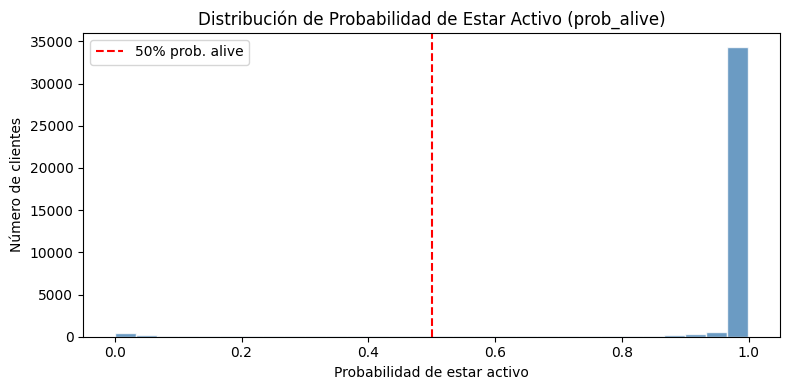

Clientes con prob_alive < 0.5 (en riesgo): 1,516
Clientes con prob_alive > 0.5 (activos): 35,991


In [48]:
# Visualización: distribución de probabilidad de fuga
plt.figure(figsize=(8, 4))
plt.hist(clv['prob_alive'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(x=0.5, color='red', linestyle='--', label='50% prob. alive')
plt.title('Distribución de Probabilidad de Estar Activo (prob_alive)')
plt.xlabel('Probabilidad de estar activo')
plt.ylabel('Número de clientes')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Clientes con prob_alive < 0.5 (en riesgo): {(clv['prob_alive'] < 0.5).sum():,}")
print(f"Clientes con prob_alive > 0.5 (activos): {(clv['prob_alive'] >= 0.5).sum():,}")

## 4. Verificación de supuesto: baja correlación frequency/monetary_value

El modelo Gamma-Gamma asume independencia entre frequency y monetary_value.
Correlación < 0.3 es aceptable.

In [12]:
corr = clv[['frequency', 'monetary_value']].corr()
print(corr)
corr_val = corr.loc['frequency', 'monetary_value']
print(f"\nCorrelación: {corr_val:.3f} — {'OK ✓' if abs(corr_val) < 0.3 else 'ADVERTENCIA: correlación alta, revisar supuesto'})")

                frequency  monetary_value
frequency        1.000000        0.211392
monetary_value   0.211392        1.000000

Correlación: 0.211 — OK ✓)


## 5. Modelo Gamma-Gamma — Customer Lifetime Value (CLV)

El modelo Gamma-Gamma estima el valor monetario esperado de las transacciones futuras,
combinado con el BG/NBD para obtener el CLV total.

Parámetros ajustables:
- `time`: horizonte temporal en meses
- `discount_rate`: tasa de descuento mensual
- `freq='D'`: frecuencia base del modelo (días)

In [13]:
from lifetimes import GammaGammaFitter

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(clv['frequency'], clv['monetary_value'])
print(ggf)

<lifetimes.GammaGammaFitter: fitted with 37507 subjects, p: 2.37, q: 0.11, v: 2.35>


In [14]:
clv['6_months_clv'] = ggf.customer_lifetime_value(
    bgf,
    clv['frequency'],
    clv['recency'],
    clv['T'],
    clv['monetary_value'],
    time=6,
    freq='D',
    discount_rate=0.01
)

clv['year_clv'] = ggf.customer_lifetime_value(
    bgf,
    clv['frequency'],
    clv['recency'],
    clv['T'],
    clv['monetary_value'],
    time=12,
    freq='D',
    discount_rate=0.01
)

clv.rename(columns={'monetary_value': 'Monto_prom'}, inplace=True)
clv.reset_index(inplace=True)
print(f"CLV promedio (1 año): {clv['year_clv'].mean():,.2f}")
clv[['customer_id', 'frequency', 'recency', 'T', 'Monto_prom', 'prob_alive', '6_months_clv', 'year_clv']].round(2).head(10)

CLV promedio (1 año): 3,308,957.65


,customer_id,frequency,recency,T,Monto_prom,prob_alive,6_months_clv,year_clv
0,235,9.0,154.0,168.0,34673.89,1.00,391926.35,757764.02
1,499,15.0,161.0,178.0,38766.53,1.00,595502.31,1151764.47
2,547,36.0,178.0,178.0,93472.53,1.00,2959731.16,5725880.08
3,665,42.0,178.0,181.0,200144.50,1.00,7169870.05,13871596.32
4,1012,25.0,175.0,175.0,57589.04,1.00,1350927.85,2613198.11
5,1144,26.0,122.0,176.0,51180.35,0.25,304120.58,588294.65
6,1158,47.0,179.0,180.0,209137.79,1.00,8330583.37,16117376.12
7,1284,16.0,168.0,172.0,98552.94,1.00,1638736.86,3169373.83
8,1327,43.0,178.0,181.0,79145.67,1.00,2895801.94,5602550.15
9,1542,25.0,175.0,180.0,400354.56,1.00,9178249.08,17755046.60


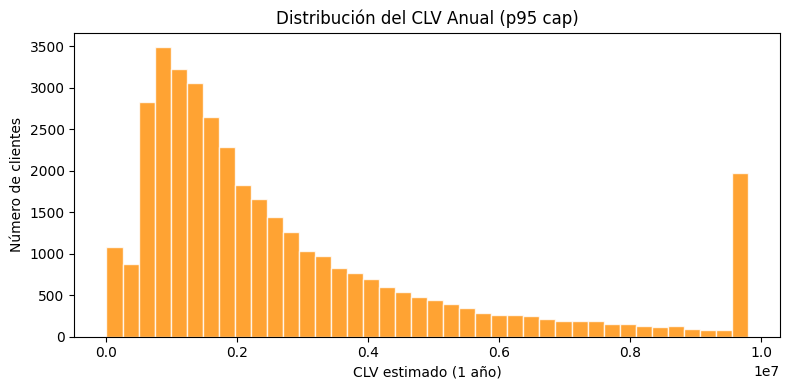

In [15]:
# Visualización: distribución del CLV anual
plt.figure(figsize=(8, 4))
plt.hist(clv['year_clv'].clip(upper=clv['year_clv'].quantile(0.95)), bins=40, color='darkorange', edgecolor='white', alpha=0.8)
plt.title('Distribución del CLV Anual (p95 cap)')
plt.xlabel('CLV estimado (1 año)')
plt.ylabel('Número de clientes')
plt.tight_layout()
plt.show()

## 6. Agregación de métricas por cliente

Combinamos el resumen RFM+CLV con métricas adicionales derivadas de las transacciones.

In [16]:
# Calcular inactividad y tiempo entre compras por cliente
fecha_maxima = df['date'].max()

extra = df.groupby('customer_id').agg(
    Gasto_total=('amount', 'sum'),
    Unidades_sum=('units', 'sum') if 'units' in df.columns else ('amount', 'count'),
    Online_prom=('channel', lambda x: (x == 'online').mean()) if 'channel' in df.columns else ('amount', lambda x: 0),
    Oferta=('discount', 'mean') if 'discount' in df.columns else ('amount', lambda x: 0),
    Inactividad=('date', lambda x: (fecha_maxima - x.max()).days),
    Tiempo_entre_compras=('date', lambda x: x.sort_values().diff().dt.days.mean() if len(x) > 1 else np.nan),
).reset_index()

# Merge con CLV
customers = extra.merge(clv, on='customer_id', how='inner')
customers['Unidades_prom'] = customers['Unidades_sum'] / customers['frequency']

print(f"Clientes en dataset final: {len(customers):,}")
customers.head()

Clientes en dataset final: 37,507


,customer_id,Gasto_total,Unidades_sum,Online_prom,Oferta,Inactividad,Tiempo_entre_compras,frequency,recency,T,Monto_prom,expected_purc_6_months,expected_purc_year,prob_alive,6_months_clv,year_clv,Unidades_prom
0,235,312065,28,0,0,14,5.703704,9.0,154.0,168.0,34673.888889,11.214452,22.326684,0.995829,3.919263e+05,7.577640e+05,3.111111
1,499,581498,52,0,0,17,3.156863,15.0,161.0,178.0,38766.533333,15.505432,30.880519,0.995193,5.955023e+05,1.151764e+06,3.466667
2,547,3365011,231,0,0,0,0.773913,36.0,178.0,178.0,93472.527778,32.439003,64.622061,0.999559,2.959731e+06,5.725880e+06,6.416667
3,665,8406069,403,0,0,3,0.442786,42.0,178.0,181.0,200144.500000,36.755225,73.224806,0.999295,7.169870e+06,1.387160e+07,9.595238
4,1012,1439726,120,0,0,0,1.470588,25.0,175.0,175.0,57589.040000,23.920874,47.647405,0.999369,1.350928e+06,2.613198e+06,4.800000


## 7. Clustering — Segmentación de clientes

Usamos KMeans con reducción dimensional PCA.

### Features para clustering
Ajusta `CLUSTERING_FEATURES` según las columnas disponibles en tu dataset.

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Ajusta esta lista según tus columnas disponibles
CLUSTERING_FEATURES = [
    'Online_prom', 'Oferta',
    'frequency', 'recency', 'T', 'Monto_prom',
    'expected_purc_year', 'year_clv',
    'Inactividad', 'Tiempo_entre_compras',
    'Unidades_prom'
]

# Filtrar columnas existentes y eliminar NaN
available_features = [f for f in CLUSTERING_FEATURES if f in customers.columns]
print(f"Features disponibles: {available_features}")

X = customers[available_features].copy()
X = X.dropna()
customers_clean = customers.loc[X.index].copy()
print(f"Clientes tras dropna: {len(X):,}")

Features disponibles: ['Online_prom', 'Oferta', 'frequency', 'recency', 'T', 'Monto_prom', 'expected_purc_year', 'year_clv', 'Inactividad', 'Tiempo_entre_compras', 'Unidades_prom']
Clientes tras dropna: 37,507


In [18]:
# Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 7.1 PCA — Reducción dimensional

El gráfico de varianza acumulada ayuda a elegir cuántas componentes retener.
Como regla general, retener 80-95% de la varianza explicada.

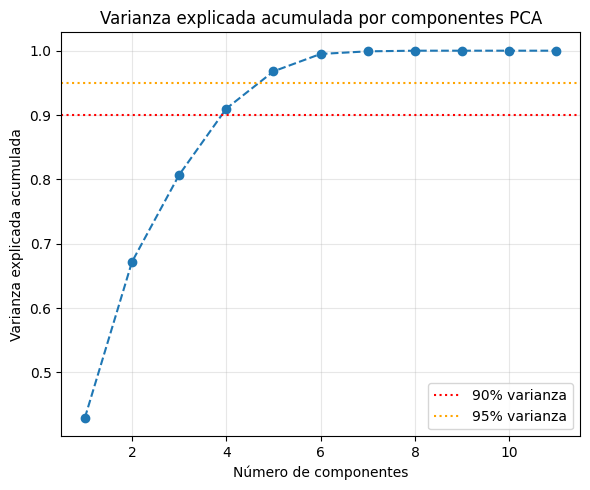

Componentes para 90% varianza: 4


In [19]:
pca_full = PCA()
pca_full.fit(X_scaled)
cumvar = pca_full.explained_variance_ratio_.cumsum()
n_components_total = len(cumvar)

plt.figure(figsize=(6, 5))
plt.plot(range(1, n_components_total + 1), cumvar, marker='o', linestyle='--')
plt.axhline(y=0.90, color='red', linestyle=':', label='90% varianza')
plt.axhline(y=0.95, color='orange', linestyle=':', label='95% varianza')
plt.title('Varianza explicada acumulada por componentes PCA')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Número de componentes para 90% de varianza
n_components_90 = np.argmax(cumvar >= 0.90) + 1
print(f"Componentes para 90% varianza: {n_components_90}")

In [20]:
# Ajusta N_COMPONENTS según el gráfico anterior
N_COMPONENTS = n_components_90  # o define manualmente, ej: N_COMPONENTS = 8

pca = PCA(n_components=N_COMPONENTS)
X_pca = pca.fit_transform(X_scaled)
print(f"Varianza explicada con {N_COMPONENTS} componentes: {pca.explained_variance_ratio_.sum():.2%}")

Varianza explicada con 4 componentes: 91.00%


### 7.2 Método del codo — Número óptimo de clusters

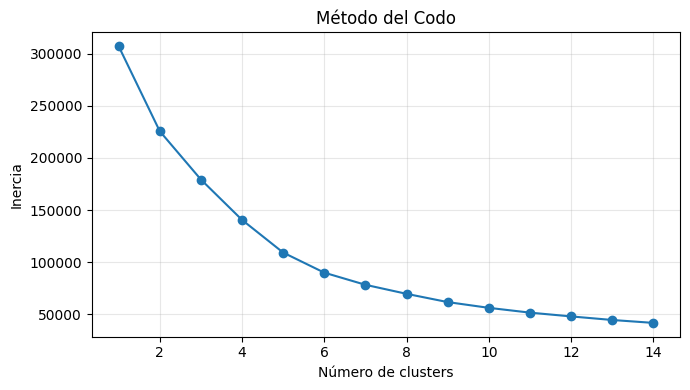

In [21]:
# Método del codo (inercia)
inercia = []
K_range = range(1, 15)
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=0)
    km.fit(X_pca)
    inercia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inercia, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

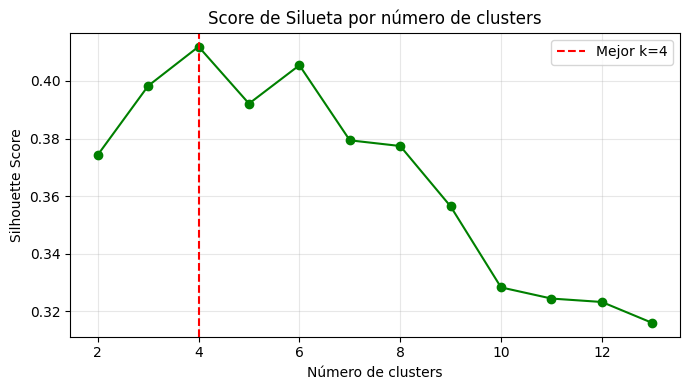

K sugerido por silueta: 4


In [22]:
# Score de silueta para validar el número de clusters
from sklearn.metrics import silhouette_score
from sklearn.utils import shuffle as sk_shuffle

sample_size = min(3000, len(X_pca))
X_sample = X_pca[:sample_size]

sil_scores = []
K_range_sil = range(2, 14)
for k in K_range_sil:
    km = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=0)
    labels = km.fit_predict(X_sample)
    sil_scores.append(silhouette_score(X_sample, labels))

best_k = K_range_sil[np.argmax(sil_scores)]
plt.figure(figsize=(7, 4))
plt.plot(K_range_sil, sil_scores, marker='o', color='green')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Mejor k={best_k}')
plt.title('Score de Silueta por número de clusters')
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"K sugerido por silueta: {best_k}")

### 7.3 Ajuste del modelo KMeans

Ajusta `N_CLUSTERS` basándote en el codo y la silueta.

In [23]:
N_CLUSTERS = best_k  # o define manualmente, ej: N_CLUSTERS = 8

kmeans = KMeans(n_clusters=N_CLUSTERS, init='k-means++', max_iter=300, n_init=10, random_state=0)
kmeans.fit(X_pca)
customers_clean['cluster'] = kmeans.labels_
print(f"Distribución de clusters:\n{customers_clean['cluster'].value_counts().sort_index()}")

Distribución de clusters:
cluster
0    16193
1    16997
2     4001
3      316
Name: count, dtype: int64


## 8. Perfilado de clusters y asignación de segmentos

Calculamos el promedio de cada métrica por cluster para interpretar su significado
y asignamos nombres descriptivos basados en las características dominantes.

In [27]:
profile_cols = [
    'Gasto_total', 'Unidades_sum', 'Online_prom', 'Oferta',
    'frequency', 'recency', 'T', 'Monto_prom',
    'expected_purc_6_months', 'expected_purc_year',
    '6_months_clv', 'year_clv', 'prob_alive',
    'Inactividad', 'Tiempo_entre_compras', 'Unidades_prom', 'cluster'
]
available_profile = [c for c in profile_cols if c in customers_clean.columns]

customers_clean[available_profile] = customers_clean[available_profile].apply(pd.to_numeric, errors='coerce')
grouped_df = customers_clean[available_profile].groupby('cluster').mean().round(2)
grouped_df['Cantidad'] = customers_clean.groupby('cluster').size()
grouped_df

,Gasto_total,Unidades_sum,Online_prom,Oferta,frequency,recency,T,Monto_prom,expected_purc_6_months,expected_purc_year,6_months_clv,year_clv,prob_alive,Inactividad,Tiempo_entre_compras,Unidades_prom,Cantidad
cluster,,,,,,,,,,,,,,,,,
0,573042.26,40.61,0.0,0.0,10.36,156.14,169.61,55981.01,12.18,24.26,679680.69,1314204.36,0.99,13.48,5.34,3.97,16193
1,2627333.64,159.86,0.0,0.0,23.91,172.08,176.75,108824.97,22.80,45.42,2455576.70,4750021.20,1.00,4.67,1.45,6.66,16997
2,448098.66,29.16,0.0,0.0,5.27,55.73,118.87,77977.25,9.36,18.61,813557.15,1570048.33,0.66,63.14,3.37,5.17,4001
3,28147726.83,818.52,0.0,0.0,28.84,168.96,173.77,1012911.69,26.92,53.63,25864800.27,50032562.34,0.99,4.81,0.33,29.05,316


In [28]:
# Asignación de nombres de segmento basada en métricas dominantes
# Ajusta o amplía estos segmentos según el número de clusters y tu negocio

segment_map = {}

# VIP: mayor frecuencia de compra
segment_map[grouped_df['frequency'].idxmax()] = 'VIP'

# Inactivo: menor probabilidad de estar activo
if 'prob_alive' in grouped_df.columns:
    segment_map[grouped_df['prob_alive'].idxmin()] = 'Inactivo'

# Esporádico: mayor tiempo entre compras
if 'Tiempo_entre_compras' in grouped_df.columns:
    segment_map[grouped_df['Tiempo_entre_compras'].idxmax()] = 'Esporádico'

# Oportunista: mayor uso de descuentos
if 'Oferta' in grouped_df.columns:
    segment_map[grouped_df['Oferta'].idxmax()] = 'Oportunista'

# Fiel: segunda mayor frecuencia (si no está asignada)
freq_sorted = grouped_df['frequency'].sort_values(ascending=False)
for idx in freq_sorted.index:
    if idx not in segment_map:
        segment_map[idx] = 'Fiel'
        break

# Resto: Estándar
grouped_df['segmento'] = grouped_df.index.map(lambda x: segment_map.get(x, 'Estándar'))
grouped_df.reset_index(inplace=True)

# Unir segmento al dataframe de clientes
customers_clean = customers_clean.merge(
    grouped_df[['cluster', 'segmento']], on='cluster', how='left'
)

print(customers_clean['segmento'].value_counts())
grouped_df[['cluster', 'segmento', 'frequency', 'prob_alive', 'year_clv', 'Cantidad']]

segmento
Fiel           16997
Oportunista    16193
Inactivo        4001
VIP              316
Name: count, dtype: int64


,cluster,segmento,frequency,prob_alive,year_clv,Cantidad
0,0,Oportunista,10.36,0.99,1314204.36,16193
1,1,Fiel,23.91,1.00,4750021.20,16997
2,2,Inactivo,5.27,0.66,1570048.33,4001
3,3,VIP,28.84,0.99,50032562.34,316


## 9. Visualizaciones

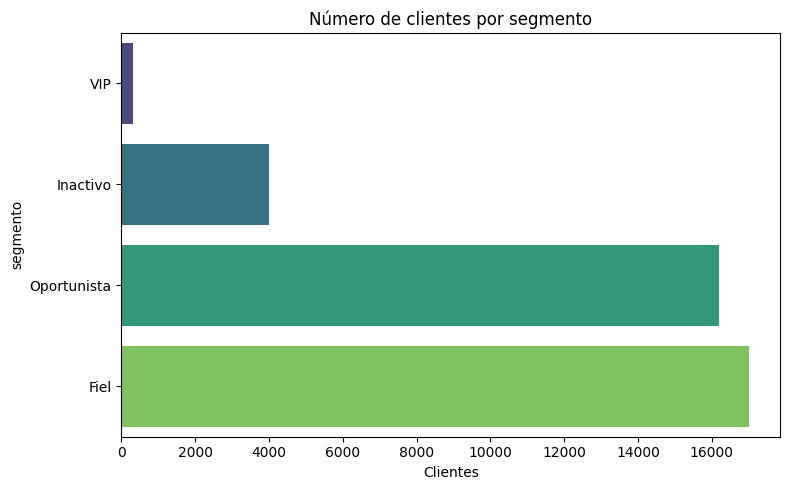

In [29]:
import seaborn as sns

# Distribución de clientes por segmento
counts = customers_clean['segmento'].value_counts().sort_values()
plt.figure(figsize=(8, 5))
sns.barplot(x=counts.values, y=counts.index, palette='viridis')
plt.title('Número de clientes por segmento')
plt.xlabel('Clientes')
plt.tight_layout()
plt.show()

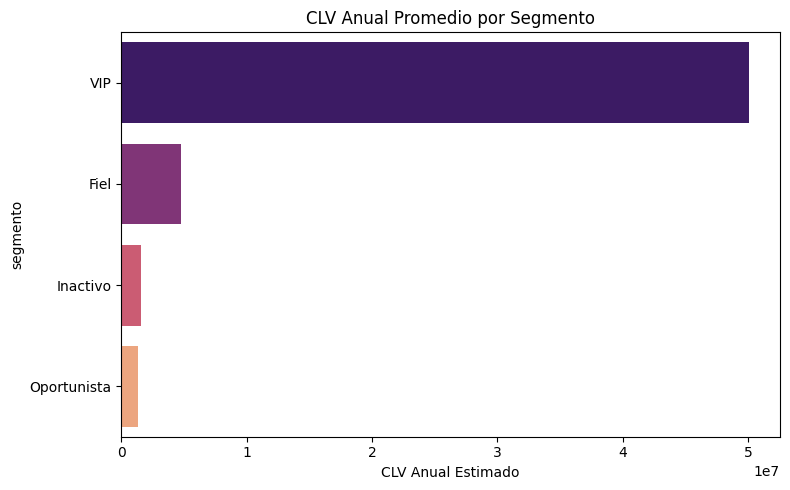

In [30]:
# CLV anual promedio por segmento
if 'year_clv' in customers_clean.columns:
    clv_by_segment = customers_clean.groupby('segmento')['year_clv'].mean().sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=clv_by_segment.values, y=clv_by_segment.index, palette='magma')
    plt.title('CLV Anual Promedio por Segmento')
    plt.xlabel('CLV Anual Estimado')
    plt.tight_layout()
    plt.show()

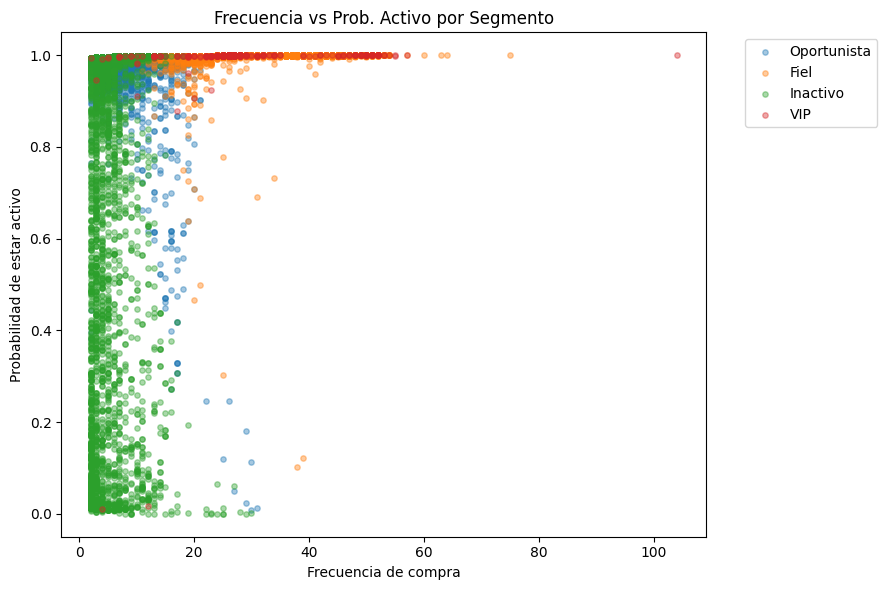

In [31]:
# prob_alive vs frequency scatter por segmento
if 'prob_alive' in customers_clean.columns:
    plt.figure(figsize=(9, 6))
    for seg in customers_clean['segmento'].unique():
        subset = customers_clean[customers_clean['segmento'] == seg]
        plt.scatter(subset['frequency'], subset['prob_alive'], label=seg, alpha=0.4, s=15)
    plt.xlabel('Frecuencia de compra')
    plt.ylabel('Probabilidad de estar activo')
    plt.title('Frecuencia vs Prob. Activo por Segmento')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## 10. Exportar resultados

In [ ]:
output_cols = ['customer_id', 'frequency', 'recency', 'T', 'Monto_prom',
               'prob_alive', 'expected_purc_6_months', 'expected_purc_year',
               '6_months_clv', 'year_clv', 'cluster', 'segmento']
output_cols = [c for c in output_cols if c in customers_clean.columns]

output = customers_clean[output_cols].copy()
output.to_csv('customers_clv_segments.csv', index=False)
print(f"Exportado: customers_clv_segments.csv ({len(output):,} filas)")
output.head(10)